In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_parquet('../data//processed/orders.parquet')
order_products_prior = pd.read_parquet('../data/processed/order_products__prior.parquet')
products = pd.read_parquet('../data/processed/products.parquet')

In [3]:
# 1. Global Top Products (The "Option B" fallback)
top_products = order_products_prior['product_id'].value_counts().head(10).reset_index()
top_products.columns = ['product_id', 'count']
top_products = top_products.merge(products[['product_id', 'product_name']], on='product_id')

print("Global Top 10 Products for New Users:")
print(top_products[['product_name', 'count']])

Global Top 10 Products for New Users:
             product_name   count
0                  Banana  472565
1  Bag of Organic Bananas  379450
2    Organic Strawberries  264683
3    Organic Baby Spinach  241921
4    Organic Hass Avocado  213584
5         Organic Avocado  176815
6             Large Lemon  152657
7            Strawberries  142951
8                   Limes  140627
9      Organic Whole Milk  137905


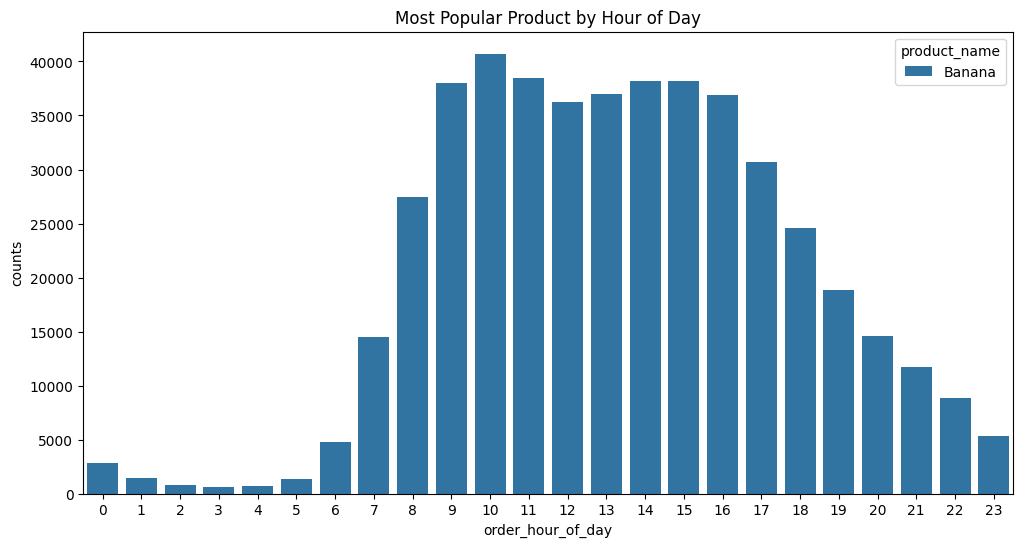

In [4]:
# 2. Trending by Hour (Contextual Recommendations)
# Does the top product change at 8 AM vs 8 PM?
hourly_counts = orders.merge(order_products_prior, on='order_id')
hourly_top = hourly_counts.groupby(['order_hour_of_day', 'product_id']).size().reset_index(name='counts')
hourly_top = hourly_top.sort_values(['order_hour_of_day', 'counts'], ascending=[True, False]).groupby('order_hour_of_day').head(1)

# Visualize the trend
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_top.merge(products, on='product_id'), x='order_hour_of_day', y='counts', hue='product_name')
plt.title("Most Popular Product by Hour of Day")
plt.show()